# Week 8 - Notebook 1: K-Means Clustering + PCA

This week is about unsupervised learning, meaning there's no "answer key" (no y column)
that the model is trying to predict. Instead we're just looking for natural groups/patterns
in the data on its own.

I'm using the Wine dataset for this. It has 13 different chemical measurements for 178 wines
(alcohol, acidity, color, etc). It actually does have real labels (3 wine types), but I'm going
to pretend I don't know them, cluster the data with K-Means, and then check afterwards how well
the clusters line up with the real wine types.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

Step 1: Load the data

In [3]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
true_labels = wine.target   # the real wine type, only used later to check our clusters

print(X.shape)
X.head()

(178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


Step 2: Scale the features

K-Means uses distance between points to decide which cluster something belongs to. If one column is measured in the hundreds (like "proline") and another is measured between 0 and 5 (like "ash"), the big column will dominate the distance completely. Scaling puts every column on the same footing.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("before scaling, column ranges look very different:")
print(X.describe().loc[["min", "max"]].T.head())

before scaling, column ranges look very different:
                     min     max
alcohol            11.03   14.83
malic_acid          0.74    5.80
ash                 1.36    3.23
alcalinity_of_ash  10.60   30.00
magnesium          70.00  162.00


Step 3: How many clusters should we use? (the elbow method)

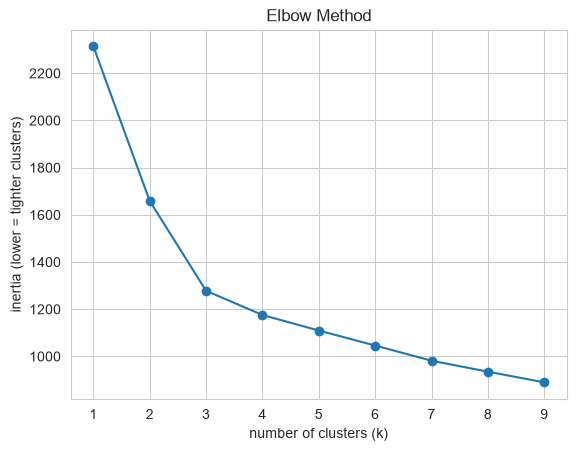

the 'elbow' (where the line bends and flattens out) looks like it's around k=3,
which actually matches that we know there are 3 real wine types in this data.


In [5]:
inertia_values = []
k_range = range(1, 10)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

plt.plot(k_range, inertia_values, marker="o")
plt.xlabel("number of clusters (k)")
plt.ylabel("inertia (lower = tighter clusters)")
plt.title("Elbow Method")
plt.show()

print("the 'elbow' (where the line bends and flattens out) looks like it's around k=3,")
print("which actually matches that we know there are 3 real wine types in this data.")

Step 4: Run K-Means with k=3

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

X["cluster"] = cluster_labels
X["cluster"].value_counts()

cluster
0    65
2    62
1    51
Name: count, dtype: int64

Step 5: PCA - shrinking 13 columns down to 2, just so we can actually see it

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("shape before PCA:", X_scaled.shape)
print("shape after PCA :", X_pca.shape)
print()
print("variance explained by each of the 2 components:", pca.explained_variance_ratio_.round(2))
print("total variance kept:", round(pca.explained_variance_ratio_.sum(), 2),
      "-> a little over half the original information survived the drop from 13 columns to 2,")
print("which is a normal trade-off - we're sacrificing some detail purely so we can plot it.")

shape before PCA: (178, 13)
shape after PCA : (178, 2)

variance explained by each of the 2 components: [0.36 0.19]
total variance kept: 0.55 -> a little over half the original information survived the drop from 13 columns to 2,
which is a normal trade-off - we're sacrificing some detail purely so we can plot it.


Step 6: Visualize the clusters on the PCA plot

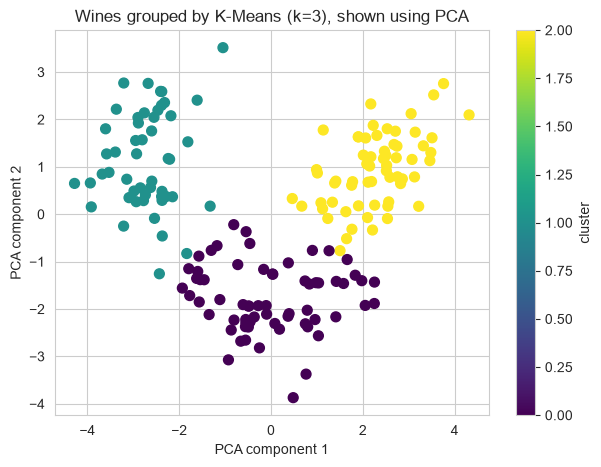

In [8]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="viridis", s=50)
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("Wines grouped by K-Means (k=3), shown using PCA")
plt.colorbar(scatter, label="cluster")
plt.show()

## Step 7: Did the clusters actually match the real wine types?

Since this dataset happens to come with real labels, we can check: did K-Means (which never
saw the real labels) end up finding roughly the same 3 groups anyway?

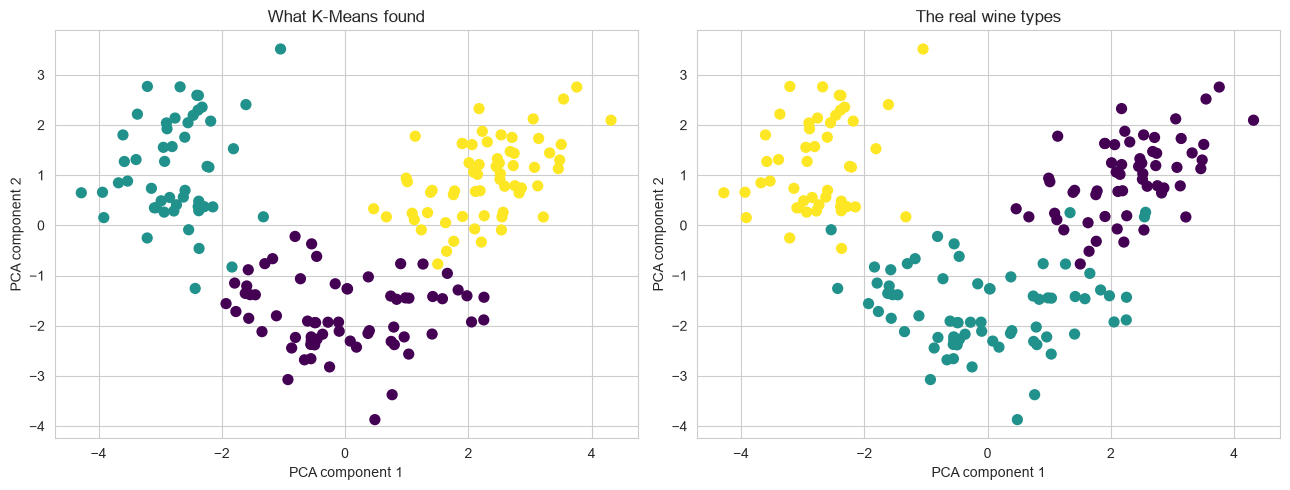

comparing cluster number to real wine type for each wine:
real wine type    0   1   2
K-Means cluster            
0                 0  65   0
1                 0   3  48
2                59   3   0


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="viridis", s=50)
axes[0].set_title("What K-Means found")
axes[0].set_xlabel("PCA component 1")
axes[0].set_ylabel("PCA component 2")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=true_labels, cmap="viridis", s=50)
axes[1].set_title("The real wine types")
axes[1].set_xlabel("PCA component 1")
axes[1].set_ylabel("PCA component 2")

plt.tight_layout()
plt.show()

print("comparing cluster number to real wine type for each wine:")
comparison_table = pd.crosstab(cluster_labels, true_labels,
                                rownames=["K-Means cluster"], colnames=["real wine type"])
print(comparison_table)

## What I learned from this

- K-Means found 3 groups purely based on the chemical measurements without being told the real wine type. Looking at the comparison table most wines in each cluster do belong to the real wine type meaning the clusters lined up with reality pretty well the chemistry alone was enough to tell the wines apart

- PCA let us actually see 13 dimensional data on a normal chart by keeping the 2 directions that carry the most information In this case those 2 directions only captured a little over half of the total variance in the data so the 2D picture is a simplified summary not the full story. It was still enough to see the 3 wine groups separate clearly

- The main limitation K Meams assumes clusters are round like blobs of similar size which won't always be true, for every dataset it worked well here because the wine types really do separate cleanly along a few chemical properties